
📊 ANALYSIS FOR: Multiple Phone (First 5 vs Last 5)

📌 Descriptive Statistics:
        first_five    last_five
count    13.000000    13.000000
mean   2029.320231  1902.317123
std     769.088460   506.076411
min    1266.800000  1086.800000
25%    1360.600000  1598.000000
50%    1799.600000  1795.660000
75%    2542.600000  2190.800000
max    3957.833000  3114.333000

📌 Shapiro-Wilk Normality Test on Differences:
Statistic = 0.9295, p-value = 0.3354


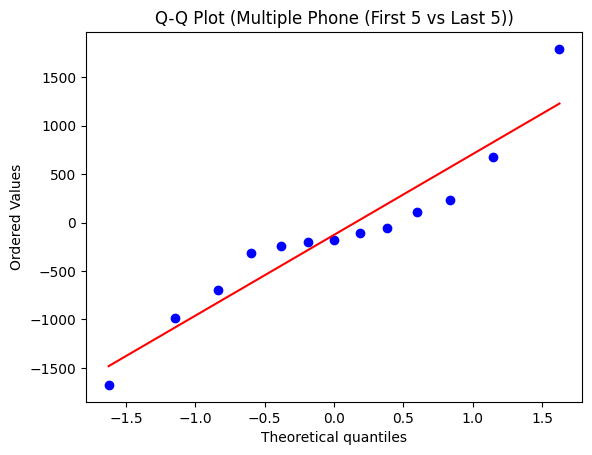

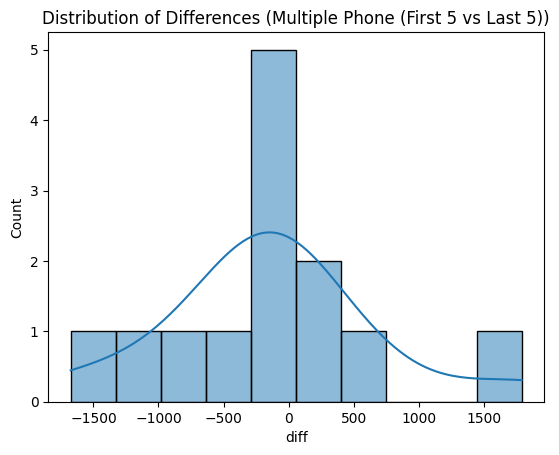

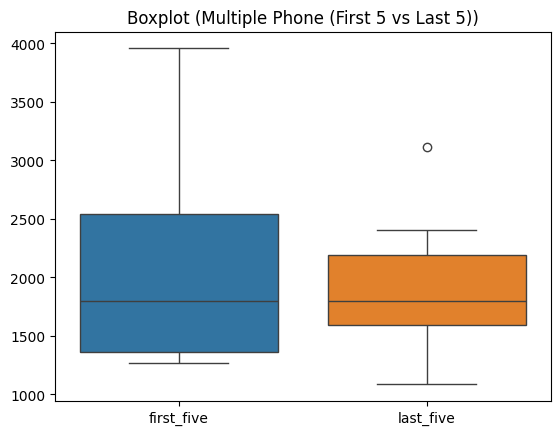


✅ Data is approximately NORMAL → Using Paired t-test
t-statistic = 0.5598, p-value = 0.5859
👉 No significant difference (Fail to reject H0)

📌 Interpretation:
👉 Reaction time decreased → Learning effect

📌 Report Sentence:

Normality of difference scores was assessed using the Shapiro-Wilk test (p = 0.335).
As normality was satisfied, a paired samples t-test was conducted.
Results did not show a significant difference (p = 0.586).


📌 Reason for Non-Normality (if applicable):

Reaction time data is often positively skewed due to:
- Natural lower bound (cannot be < 0)
- Occasional slow responses (outliers)
- Cognitive variability across participants
This violates the normality assumption required for parametric tests.


✅ Test Used: Paired t-test


📊 ANALYSIS FOR: Single Phone (First 8 vs Last 7)

📌 Descriptive Statistics:
       first_eight   last_seven
count    20.000000    20.000000
mean   2031.158750  3954.326000
std     462.018312  1056.346319
min    1555.800000  2606.625000
25%  

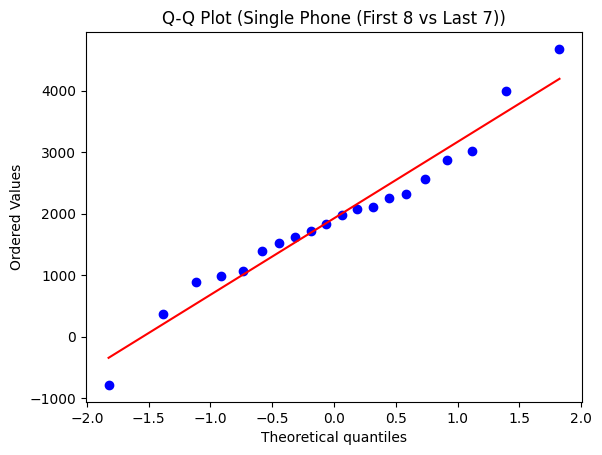

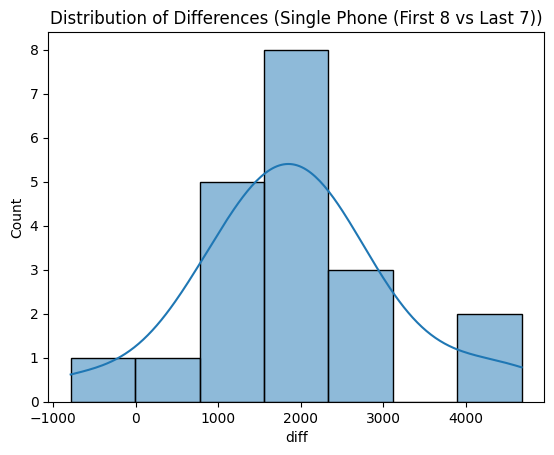

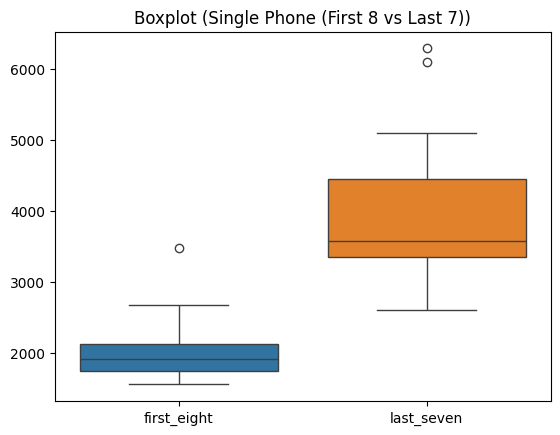


✅ Data is approximately NORMAL → Using Paired t-test
t-statistic = -7.1232, p-value = 0.0000
👉 Significant difference found (Reject H0)

📌 Interpretation:
👉 Reaction time increased → Fatigue / difficulty effect

📌 Report Sentence:

Normality of difference scores was assessed using the Shapiro-Wilk test (p = 0.798).
As normality was satisfied, a paired samples t-test was conducted.
Results showed a significant difference (p = 0.000).


📌 Reason for Non-Normality (if applicable):

Reaction time data is often positively skewed due to:
- Natural lower bound (cannot be < 0)
- Occasional slow responses (outliers)
- Cognitive variability across participants
This violates the normality assumption required for parametric tests.


✅ Test Used: Paired t-test



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# -----------------------------
# 1. CREATE DATASETS
# -----------------------------

# Dataset 1
data1 = [
(2544,1559),(3957.833,2283),(1266.8,1086.8),(2542.6,1842.5),
(2718.2,2405.66),(1292.6,1965.71),(1686.6,1795.66),(1360.6,1597.833),
(1843,1598),(1799.6,1602.66),(2247.8,2190.8),(1798.2,1688.1666),
(1323.33,3114.333)
]

df1 = pd.DataFrame(data1, columns=["first_five","last_five"])
df1["diff"] = df1["last_five"] - df1["first_five"]


# Dataset 2
data2 = [
(3474,2688.28),(2675.125,4783.125),(1753,2821.125),(1713.125,3962),
(2185,5057.4),(2098.125,4168.85),(1555.8,3535.25),(1973.875,3500.28),
(1772.5,4333.42),(1848.625,3468),(2474.75,2848.85),(1818,4136.85),
(1611.125,6288.43),(1627,2606.625),(1893.5,3615.14),(1576.125,3398.85),
(1917.875,3315.625),(2472.25,3362),(2077.125,5100.28),(2106.25,6096.14)
]

df2 = pd.DataFrame(data2, columns=["first_eight","last_seven"])
df2["diff"] = df2["last_seven"] - df2["first_eight"]


# -----------------------------
# 2. FUNCTION FOR FULL ANALYSIS
# -----------------------------

def analyze_dataset(df, name, col1, col2):

    print(f"\n{'='*50}")
    print(f"📊 ANALYSIS FOR: {name}")
    print(f"{'='*50}\n")

    diff = df["diff"]

    # -----------------------------
    # DESCRIPTIVE STATS
    # -----------------------------
    print("📌 Descriptive Statistics:")
    print(df[[col1, col2]].describe())

    # -----------------------------
    # NORMALITY TEST
    # -----------------------------
    print("\n📌 Shapiro-Wilk Normality Test on Differences:")
    shapiro_stat, shapiro_p = stats.shapiro(diff)
    print(f"Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

    # -----------------------------
    # Q-Q PLOT
    # -----------------------------
    plt.figure()
    stats.probplot(diff, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot ({name})")
    plt.show()

    # -----------------------------
    # HISTOGRAM
    # -----------------------------
    plt.figure()
    sns.histplot(diff, kde=True)
    plt.title(f"Distribution of Differences ({name})")
    plt.show()

    # -----------------------------
    # BOXPLOT
    # -----------------------------
    plt.figure()
    sns.boxplot(data=df[[col1, col2]])
    plt.title(f"Boxplot ({name})")
    plt.show()

    # -----------------------------
    # DECISION
    # -----------------------------
    if shapiro_p > 0.05:
        print("\n✅ Data is approximately NORMAL → Using Paired t-test")

        t_stat, p_val = stats.ttest_rel(df[col1], df[col2])

        print(f"t-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")

        if p_val <= 0.05:
            print("👉 Significant difference found (Reject H0)")
        else:
            print("👉 No significant difference (Fail to reject H0)")

        test_used = "Paired t-test"

    else:
        print("\n⚠️ Data is NON-NORMAL → Using Wilcoxon Signed-Rank Test")

        w_stat, p_val = stats.wilcoxon(df[col1], df[col2])

        print(f"W-statistic = {w_stat:.4f}, p-value = {p_val:.4f}")

        if p_val <= 0.05:
            print("👉 Significant difference found (Reject H0)")
        else:
            print("👉 No significant difference (Fail to reject H0)")

        test_used = "Wilcoxon Signed-Rank Test"

    # -----------------------------
    # INTERPRETATION
    # -----------------------------
    mean_diff = np.mean(diff)

    print("\n📌 Interpretation:")

    if mean_diff < 0:
        print("👉 Reaction time decreased → Learning effect")
    else:
        print("👉 Reaction time increased → Fatigue / difficulty effect")

    print("\n📌 Report Sentence:")

    if shapiro_p > 0.05:
        print(f"""
Normality of difference scores was assessed using the Shapiro-Wilk test (p = {shapiro_p:.3f}).
As normality was satisfied, a paired samples t-test was conducted.
Results {'showed' if p_val <= 0.05 else 'did not show'} a significant difference (p = {p_val:.3f}).
""")
    else:
        print(f"""
Normality of difference scores was assessed using the Shapiro-Wilk test (p = {shapiro_p:.3f}),
indicating violation of normality. Therefore, a Wilcoxon signed-rank test was used.
Results {'showed' if p_val <= 0.05 else 'did not show'} a significant difference (p = {p_val:.3f}).
""")

    print("\n📌 Reason for Non-Normality (if applicable):")
    print("""
Reaction time data is often positively skewed due to:
- Natural lower bound (cannot be < 0)
- Occasional slow responses (outliers)
- Cognitive variability across participants
This violates the normality assumption required for parametric tests.
""")

    print(f"\n✅ Test Used: {test_used}")
    print(f"{'='*50}\n")


# -----------------------------
# 3. RUN ANALYSIS
# -----------------------------

analyze_dataset(df1, "Multiple Phone (First 5 vs Last 5)", "first_five", "last_five")
analyze_dataset(df2, "Single Phone (First 8 vs Last 7)", "first_eight", "last_seven")

# 📊 Dataset 1 (Multiple Phone: First 5 vs Last 5)

Visual inspection of the Q-Q plot and the Shapiro–Wilk test (p = 0.335) indicated approximate normality of the difference scores. Therefore, a paired samples t-test was conducted. The results showed no significant difference in reaction time between early and later levels (p = 0.586).

Although the mean reaction time showed a slight decrease across levels, suggesting a **potential learning effect**, this change was not statistically significant. This indicates that participants did not exhibit a strong or consistent improvement in performance over time. The absence of a significant effect suggests that the learning rate was low or inconsistent across participants, and task demands remained relatively stable, without a clear increase in difficulty or fatigue effects.

# 📊 Dataset 2 (Single Phone: First 8 vs Last 7)

Visual inspection of the Q-Q plot and the Shapiro–Wilk test (p = 0.798) confirmed normality of the difference scores. A paired samples t-test revealed a statistically significant increase in reaction time in later levels (p < 0.001).

This increase indicates a deterioration in performance over time, suggesting the presence of **fatigue effects and/or increasing task difficulty.** As participants progressed through the levels, their responses became slower, which may reflect cognitive overload, reduced attention, or escalating task complexity. The consistent increase in reaction time implies that fatigue accumulation or difficulty progression outweighed any potential learning benefits, resulting in a negative performance trend.